# EC Sprint 3 — MindLink — She Leads — AED com dados reais

**Disciplina:** Statistical Methods for Data Science & Machine Learning  
**Professor:** Fernando Nemec  
**Projeto:** MindLink — Painel Analítico-Preditivo de Demência no SUS  
**Equipe:** She Leads — 1TSCPF

| RM | Integrante |
|---:|---|
| 572387 | Ana Júlia Amorim |
| 569873 | Beatriz Dias da Silva |
| 570351 | Luana Ramos Rabelo |
| 572886 | Mariana Ishikawa |
| 568651 | Sthefany Feitosa da Silva |

## Objetivo
Realizar uma **Análise Exploratória de Dados (AED)** robusta sobre o recorte real da Sprint 3, avaliando qualidade, distribuições, medidas de localização e dispersão, valores faltantes, outliers, relações entre variáveis e viabilidade de uso dos dados nas próximas etapas preditivas.

**Recorte analisado:** Estado de São Paulo, competências **202401 a 202512**, integrando internações SIH/SUS, diagnósticos secundários/comorbidades e capacidade hospitalar CNES.


## 1. Controle metodológico e rastreabilidade

Esta versão **não usa dados sintéticos**. O arquivo `mindlink_dataset_unificado_real.csv` foi reconstruído a partir do DML validado da Sprint 3 e contém as três fontes já carregadas no Oracle:

- `STG_MINDLINK_INTERNACOES`: 3.305 linhas agregadas;
- `STG_MINDLINK_COMORBIDADES`: 1.868 linhas;
- `STG_MINDLINK_CAPACIDADE`: 6.637 linhas.

### Limitação importante
O DML atualmente validado possui, na staging de internações, **CID principal iniciado por F00, F01, F02, F03 ou G30**. A versão revisada do ETL Python já implementa detecção de demência também em diagnósticos secundários, mas esse novo fluxo ainda precisa ser recarregado/validado no Oracle para que a equipe possa quantificar casos em que a demência aparece **somente como diagnóstico secundário**.

Assim, esta AED descreve fielmente o conjunto real atualmente persistido e **não transforma a hipótese de subnotificação por diagnóstico secundário em resultado já comprovado**.

In [1]:
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

ROOT = Path(".")
DATASET = ROOT / "mindlink_dataset_unificado_real.csv"
DICIONARIO = ROOT / "mindlink_dicionario_dados.csv"

if not DATASET.exists():
    raise FileNotFoundError("Dataset real não encontrado. Mantenha o CSV na mesma pasta do notebook.")

df = pd.read_csv(DATASET, dtype={"CODIGO_IBGE":str, "CNES":str, "CID_PRINCIPAL":str})
df["DATA_COMPETENCIA"] = pd.to_datetime(df["DATA_COMPETENCIA"])
print(f"Linhas analíticas: {len(df):,}")
print(f"Colunas: {df.shape[1]}")
print(f"Internações representadas: {df['QTD_INTERNACOES'].sum():,}")
print(f"Competências: {df['COMPETENCIA'].nunique()} | {df['COMPETENCIA'].min()} a {df['COMPETENCIA'].max()}")
display(df.head())

Linhas analíticas: 3,305
Colunas: 32
Internações representadas: 6,986
Competências: 24 | 202401 a 202512


,COMPETENCIA,CODIGO_IBGE,MUNICIPIO_ATENDIMENTO,CNES,NOME_ESTABELECIMENTO,CID_PRINCIPAL,DESCRICAO_CID_PRINCIPAL,FAIXA_ETARIA,SEXO_DESC,QTD_INTERNACOES,DIAS_PERMANENCIA,VALOR_TOTAL,QTD_OBITOS,DS_TIPO_UNIDADE,TP_GESTAO,LEITOS_EXISTENTES,LEITOS_SUS,UTI_TOTAL_EXIST,UTI_TOTAL_SUS,QTD_COMORBIDADES,CIDS_SECUNDARIOS_DISTINTOS,ANO,MES,DATA_COMPETENCIA,CID_GRUPO,DIAS_POR_INTERNACAO,VALOR_POR_INTERNACAO,TAXA_OBITO_PCT,DIAS_MES,LEITOS_DIA_SUS,PRESSAO_DEMENCIA_PCT,CAPACIDADE_CNES_DISPONIVEL
0,202401,350130,ALVARES MACHADO,2080508,SANTA CASA DE ALVARES MACHADO,F03,Demência não especificada,70_79,FEMININO,1,4,52.220,0,HOSPITAL GERAL,M,18.000,16.000,0.000,0.000,1,1,2024,1,2024-01-01,F03,4.000,52.220,0.000,31,496.000,0.806,SIM
1,202401,350170,AMERICO BRASILIENSE,6164366,HOSPITAL ESTADUAL AMERICO BRASILIENSE,F013,"Demência vascular mista, cortical e subcortical",70_79,FEMININO,1,2,328.230,0,HOSPITAL GERAL,E,84.000,84.000,10.000,10.000,1,1,2024,1,2024-01-01,F01,2.000,328.230,0.000,31,"2,604.000",0.077,SIM
2,202401,350190,AMPARO,2078848,SANTA CASA ANNA CINTRA,F001,Demência na doença de Alzheimer de início tardio,ATE_59,MASCULINO,1,2,57.000,0,HOSPITAL GERAL,M,68.000,55.000,9.000,7.000,1,1,2024,1,2024-01-01,F00,2.000,57.000,0.000,31,"1,705.000",0.117,SIM
3,202401,350270,APIAI,2082098,HOSPITAL DR ADHEMAR DE BARROS APIAI,F001,Demência na doença de Alzheimer de início tardio,ATE_59,MASCULINO,1,4,228.000,0,HOSPITAL GERAL,M,51.000,45.000,0.000,0.000,2,2,2024,1,2024-01-01,F00,4.000,228.000,0.000,31,"1,395.000",0.287,SIM
4,202401,350280,ARACATUBA,2082675,ASSOCIACAO DE AMPARO AO EXCEPCIONAL RITINHA PR...,F03,Demência não especificada,60_69,FEMININO,2,62,"4,377.820",0,HOSPITAL GERAL,M,86.000,86.000,0.000,0.000,5,4,2024,1,2024-01-01,F03,31.000,"2,188.910",0.000,31,"2,666.000",2.326,SIM


## 2. Dataset unificado e chaves de integração

O grão da tabela de internações é **competência × município × CNES × CID principal × faixa etária × sexo**. A capacidade hospitalar é ligada por `COMPETENCIA + CODIGO_IBGE + CNES` (relação muitos-para-um). As comorbidades são agregadas no nível `COMPETENCIA + CODIGO_IBGE + CNES + CID_PRINCIPAL` antes do merge, evitando multiplicação artificial das linhas de internação.

As chaves foram mantidas como códigos, e não substituídas por textos, para preservar rastreabilidade e evitar junções por nomes sujeitos a grafia.

In [2]:
# Auditoria do grão e cobertura das chaves
chave_int = ["COMPETENCIA","CNES","CID_PRINCIPAL","FAIXA_ETARIA","SEXO_DESC"]
print("Duplicidades no grão analítico:", int(df.duplicated(chave_int).sum()))
print("Municípios:", df["CODIGO_IBGE"].nunique())
print("Estabelecimentos CNES:", df["CNES"].nunique())
print("CIDs principais distintos:", df["CID_PRINCIPAL"].nunique())
print("Cobertura CNES da integração: {:.2f}%".format(100*df["LEITOS_SUS"].notna().mean()))

Duplicidades no grão analítico: 0
Municípios: 170
Estabelecimentos CNES: 281
CIDs principais distintos: 25
Cobertura CNES da integração: 99.67%


## 3. Dicionário de dados

In [3]:
dicionario = pd.read_csv(DICIONARIO)
display(dicionario)

,campo,tipo,origem,descricao,papel_analitico,missing_qtd,missing_pct,exemplo
0,COMPETENCIA,int64,SIH/SUS + chave temporal,Competência mensal no formato AAAAMM.,chave temporal,0,0.000,202401
1,CODIGO_IBGE,object,SIH/SUS / CNES,Código do município de atendimento usado como ...,chave territorial,0,0.000,350130
2,MUNICIPIO_ATENDIMENTO,object,SIH/SUS enriquecido,Município onde ocorreu o atendimento.,atributo/medida auxiliar,0,0.000,ALVARES MACHADO
3,CNES,object,SIH/SUS / CNES,Código do estabelecimento no Cadastro Nacional...,chave de estabelecimento,0,0.000,2080508
4,NOME_ESTABELECIMENTO,object,CNES,Nome do estabelecimento de saúde.,atributo/medida auxiliar,0,0.000,SANTA CASA DE ALVARES MACHADO
5,CID_PRINCIPAL,object,SIH/SUS,Código CID-10 do diagnóstico principal.,chave clínica,0,0.000,F03
6,DESCRICAO_CID_PRINCIPAL,object,CID-10 DATASUS,Descrição oficial/normalizada do CID principal.,atributo/medida auxiliar,0,0.000,Demência não especificada
7,FAIXA_ETARIA,object,Derivada no ETL,Faixa etária agregada.,segmentação,0,0.000,70_79
8,SEXO_DESC,object,SIH/SUS,Sexo agregado.,segmentação,0,0.000,FEMININO
9,QTD_INTERNACOES,int64,SIH/SUS agregado,Quantidade de internações representadas pela l...,medida de demanda,0,0.000,1


## 4. Qualidade dos dados: missings, duplicidades e zeros

A análise diferencia **ausência real (`NaN`)** de **zero estrutural**. Por exemplo, `UTI_TOTAL_SUS = 0` pode significar que o estabelecimento não possui UTI SUS e não deve ser imputado como se estivesse faltando.

In [4]:
qualidade = pd.DataFrame({
    "campo": df.columns,
    "tipo": [str(df[c].dtype) for c in df.columns],
    "missing_qtd": [int(df[c].isna().sum()) for c in df.columns],
    "missing_pct": [100*df[c].isna().mean() for c in df.columns],
    "valores_unicos": [int(df[c].nunique(dropna=True)) for c in df.columns],
})
display(qualidade.sort_values(["missing_pct","campo"], ascending=[False,True]))

print("Linhas totalmente duplicadas:", int(df.duplicated().sum()))
print("Linhas sem correspondência de capacidade CNES:", int(df["LEITOS_SUS"].isna().sum()), f"({100*df['LEITOS_SUS'].isna().mean():.2f}%)")

for c in ["DIAS_PERMANENCIA","VALOR_TOTAL","QTD_OBITOS","LEITOS_SUS","UTI_TOTAL_SUS"]:
    s=df[c].dropna()
    print(f"{c}: zeros = {(s==0).sum():,} ({100*(s==0).mean():.2f}%)")

,campo,tipo,missing_qtd,missing_pct,valores_unicos
13,DS_TIPO_UNIDADE,object,11,0.333,5
29,LEITOS_DIA_SUS,float64,11,0.333,466
15,LEITOS_EXISTENTES,float64,11,0.333,240
16,LEITOS_SUS,float64,11,0.333,224
30,PRESSAO_DEMENCIA_PCT,float64,11,0.333,1420
14,TP_GESTAO,object,11,0.333,2
17,UTI_TOTAL_EXIST,float64,11,0.333,76
18,UTI_TOTAL_SUS,float64,11,0.333,66
21,ANO,int64,0,0.000,2
31,CAPACIDADE_CNES_DISPONIVEL,object,0,0.000,2


Linhas totalmente duplicadas: 0
Linhas sem correspondência de capacidade CNES: 11 (0.33%)
DIAS_PERMANENCIA: zeros = 151 (4.57%)
VALOR_TOTAL: zeros = 54 (1.63%)
QTD_OBITOS: zeros = 2,989 (90.44%)
LEITOS_SUS: zeros = 0 (0.00%)
UTI_TOTAL_SUS: zeros = 1,742 (52.88%)


### Estratégia para valores ausentes

- **Chaves clínicas/territoriais (CID, CNES, município):** não imputar artificialmente. Se ausentes, o registro deve ser segregado e investigado na fonte.
- **Capacidade CNES após o merge:** as 11 linhas sem correspondência (≈0,33%) são mantidas no dataset, mas excluídas apenas de métricas que exigem leitos. Não será usada média/mediana de leitos para “inventar” capacidade.
- **Zeros de UTI:** tratados como valores estruturais quando a fonte CNES informa zero.
- **Valor total ou dias de permanência iguais a zero:** manter na AED e sinalizar para auditoria de regra/faturamento; não transformar automaticamente em missing.

## 5. Métricas de localização e variabilidade

In [5]:
variaveis = [
    "QTD_INTERNACOES","DIAS_PERMANENCIA","DIAS_POR_INTERNACAO",
    "VALOR_TOTAL","VALOR_POR_INTERNACAO","QTD_OBITOS",
    "LEITOS_SUS","LEITOS_EXISTENTES","UTI_TOTAL_SUS",
    "QTD_COMORBIDADES","CIDS_SECUNDARIOS_DISTINTOS","PRESSAO_DEMENCIA_PCT"
]

rows=[]
for c in variaveis:
    s=pd.to_numeric(df[c], errors="coerce").dropna()
    rows.append({
        "variavel":c,"n":len(s),"media":s.mean(),"mediana":s.median(),
        "desvio_padrao":s.std(),"q1":s.quantile(.25),"q3":s.quantile(.75),
        "min":s.min(),"max":s.max(),"assimetria":s.skew(),
        "cv_pct": 100*s.std()/s.mean() if s.mean()!=0 else np.nan
    })
resumo=pd.DataFrame(rows)
display(resumo.round(3))

,variavel,n,media,mediana,desvio_padrao,q1,q3,min,max,assimetria,cv_pct
0,QTD_INTERNACOES,3305,2.114,1.000,7.522,1.000,1.000,1.000,109.000,9.067,355.849
1,DIAS_PERMANENCIA,3305,50.978,25.000,229.666,5.000,31.000,0.000,"3,345.000",9.026,450.521
2,DIAS_POR_INTERNACAO,3305,18.655,21.000,13.585,5.000,30.000,0.000,105.000,0.629,72.820
3,VALOR_TOTAL,3305,"3,650.326","1,370.860","16,258.374",333.730,"2,188.910",0.000,"236,190.450",8.952,445.395
4,VALOR_POR_INTERNACAO,3305,"1,328.716","1,197.000","1,269.769",325.730,"2,188.910",0.000,"24,425.750",5.446,95.564
5,QTD_OBITOS,3305,0.114,0.000,0.394,0.000,0.000,0.000,5.000,4.759,345.772
6,LEITOS_SUS,3294,304.525,191.000,352.443,86.000,290.000,11.000,"1,476.000",2.069,115.735
7,LEITOS_EXISTENTES,3294,342.307,214.000,385.321,97.500,309.250,12.000,"1,543.000",1.946,112.566
8,UTI_TOTAL_SUS,3294,33.476,0.000,58.397,0.000,39.000,0.000,225.000,2.158,174.442
9,QTD_COMORBIDADES,3305,1.203,0.000,2.696,0.000,1.000,0.000,26.000,4.762,224.073


## 6. Distribuições das variáveis

Para não confundir volume agregado com comportamento individual, a leitura principal usa também `DIAS_POR_INTERNACAO` e `VALOR_POR_INTERNACAO`. A normalidade é avaliada pelo teste de **Shapiro-Wilk**, acompanhado de assimetria e inspeção gráfica. Com milhares de observações, o p-valor tende a detectar desvios pequenos; por isso ele não é interpretado isoladamente.

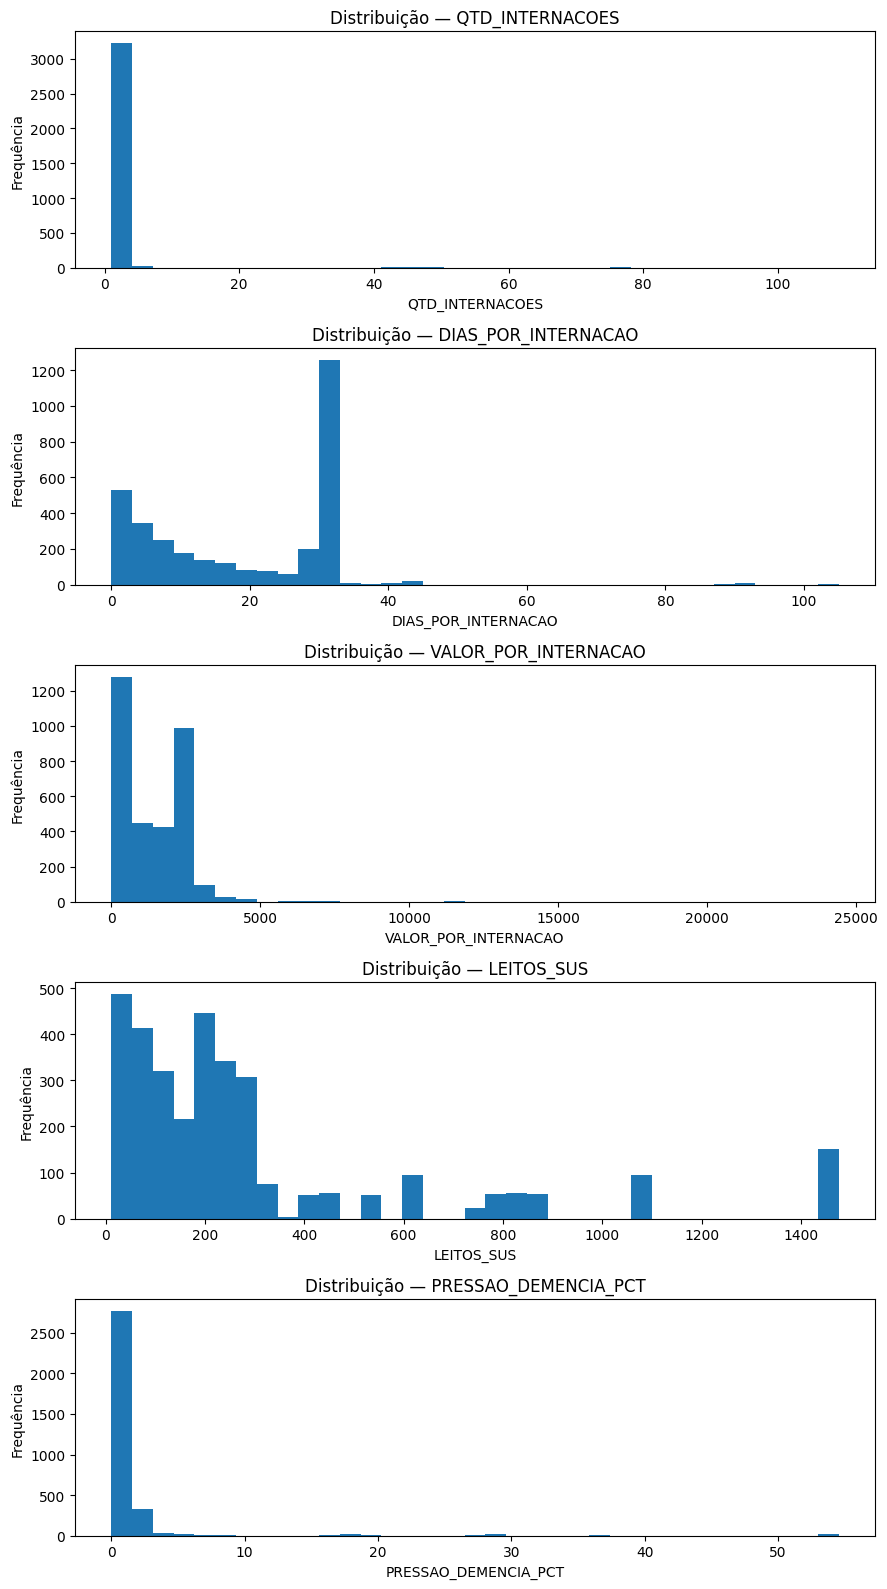

,variavel,W_Shapiro,p_valor,assimetria,normal_5pct
0,DIAS_POR_INTERNACAO,0.820,0.000,0.629,NAO
1,VALOR_POR_INTERNACAO,0.695,0.000,5.446,NAO
2,LEITOS_SUS,0.703,0.000,2.069,NAO
3,PRESSAO_DEMENCIA_PCT,0.254,0.000,6.483,NAO


QTD_INTERNACOES — média=2.114; variância=56.578; razão variância/média=26.77
A forte sobredispersão torna uma Poisson simples pouco plausível para a contagem agregada.


In [6]:
vars_dist=["QTD_INTERNACOES","DIAS_POR_INTERNACAO","VALOR_POR_INTERNACAO","LEITOS_SUS","PRESSAO_DEMENCIA_PCT"]
fig, axes = plt.subplots(len(vars_dist), 1, figsize=(9, 16))
for ax,c in zip(axes,vars_dist):
    s=df[c].dropna()
    ax.hist(s, bins=35)
    ax.set_title(f"Distribuição — {c}")
    ax.set_xlabel(c); ax.set_ylabel("Frequência")
plt.tight_layout(); plt.show()

normalidade=[]
for c in ["DIAS_POR_INTERNACAO","VALOR_POR_INTERNACAO","LEITOS_SUS","PRESSAO_DEMENCIA_PCT"]:
    s=df[c].dropna().astype(float)
    if len(s)>5000: s=s.sample(5000, random_state=42)
    W,p=stats.shapiro(s)
    normalidade.append({"variavel":c,"W_Shapiro":W,"p_valor":p,"assimetria":s.skew(),"normal_5pct":"SIM" if p>=0.05 else "NAO"})
display(pd.DataFrame(normalidade))

media_q=df["QTD_INTERNACOES"].mean(); var_q=df["QTD_INTERNACOES"].var()
print(f"QTD_INTERNACOES — média={media_q:.3f}; variância={var_q:.3f}; razão variância/média={var_q/media_q:.2f}")
print("A forte sobredispersão torna uma Poisson simples pouco plausível para a contagem agregada.")

### Leitura das distribuições

- As variáveis contínuas centrais da AED rejeitam normalidade a 5% e apresentam assimetria à direita.
- `QTD_INTERNACOES` é discreta e fortemente sobredispersa; a variância é muito superior à média. Em modelagem de contagens, isso favorece testar alternativas como **binomial negativa**, em vez de assumir Poisson automaticamente.
- Para custo, permanência e pressão, distribuições positivas assimétricas (por exemplo, Gamma ou Lognormal) podem ser avaliadas como candidatas, mas a escolha final deve ser feita no estágio de modelagem com ajuste e diagnóstico de resíduos.

## 7. Outliers

In [7]:
out=[]
for c in variaveis:
    s=df[c].dropna().astype(float)
    q1,q3=s.quantile(.25),s.quantile(.75); iqr=q3-q1
    li,ls=q1-1.5*iqr,q3+1.5*iqr
    mask=(s<li)|(s>ls)
    out.append({"variavel":c,"q1":q1,"q3":q3,"iqr":iqr,"limite_inferior":li,"limite_superior":ls,
                "outliers_qtd":int(mask.sum()),"outliers_pct":100*mask.mean()})
outliers=pd.DataFrame(out)
display(outliers.round(3))

print("Maiores permanências médias por internação:")
display(df.nlargest(10,"DIAS_POR_INTERNACAO")[["COMPETENCIA","MUNICIPIO_ATENDIMENTO","NOME_ESTABELECIMENTO","CID_PRINCIPAL","FAIXA_ETARIA","SEXO_DESC","QTD_INTERNACOES","DIAS_PERMANENCIA","DIAS_POR_INTERNACAO","VALOR_TOTAL"]])

,variavel,q1,q3,iqr,limite_inferior,limite_superior,outliers_qtd,outliers_pct
0,QTD_INTERNACOES,1.000,1.000,0.000,1.000,1.000,540,16.339
1,DIAS_PERMANENCIA,5.000,31.000,26.000,-34.000,70.000,205,6.203
2,DIAS_POR_INTERNACAO,5.000,30.000,25.000,-32.500,67.500,15,0.454
3,VALOR_TOTAL,333.730,"2,188.910","1,855.180","-2,449.040","4,971.680",236,7.141
4,VALOR_POR_INTERNACAO,325.730,"2,188.910","1,863.180","-2,469.040","4,983.680",17,0.514
5,QTD_OBITOS,0.000,0.000,0.000,0.000,0.000,316,9.561
6,LEITOS_SUS,86.000,290.000,204.000,-220.000,596.000,524,15.908
7,LEITOS_EXISTENTES,97.500,309.250,211.750,-220.125,626.875,504,15.301
8,UTI_TOTAL_SUS,0.000,39.000,39.000,-58.500,97.500,379,11.506
9,QTD_COMORBIDADES,0.000,1.000,1.000,-1.500,2.500,476,14.402


Maiores permanências médias por internação:


,COMPETENCIA,MUNICIPIO_ATENDIMENTO,NOME_ESTABELECIMENTO,CID_PRINCIPAL,FAIXA_ETARIA,SEXO_DESC,QTD_INTERNACOES,DIAS_PERMANENCIA,DIAS_POR_INTERNACAO,VALOR_TOTAL
2453,202507,CAMPINAS,REAL SOCIEDADE PORTUGUESA DE BENEFICENCIA,F03,80_89,FEMININO,1,105,105.000,"4,404.780"
2905,202510,CAMPINAS,REAL SOCIEDADE PORTUGUESA DE BENEFICENCIA,F03,80_89,FEMININO,1,105,105.000,"4,519.080"
2044,202504,CAMPINAS,REAL SOCIEDADE PORTUGUESA DE BENEFICENCIA,F03,70_79,MASCULINO,1,103,103.000,"3,093.420"
2452,202507,CAMPINAS,REAL SOCIEDADE PORTUGUESA DE BENEFICENCIA,F03,70_79,MASCULINO,1,103,103.000,"3,028.620"
2953,202510,OSASCO,PRONTO SOCORRO DR ANTONIO FLAVIO FRANCA,F03,70_79,FEMININO,1,99,99.000,44.220
2686,202508,SAO PAULO,HOSPITAL UNIVERSITARIO DA USP SAO PAULO,G308,60_69,FEMININO,1,93,93.000,81.160
348,202403,ROSANA,HOSPITAL ESTADUAL PORTO PRIMAVERA ROSANA,G308,90_MAIS,FEMININO,1,91,91.000,"2,664.460"
1162,202409,ROSANA,HOSPITAL ESTADUAL PORTO PRIMAVERA ROSANA,G308,90_MAIS,FEMININO,1,91,91.000,"2,607.080"
1570,202412,ROSANA,HOSPITAL ESTADUAL PORTO PRIMAVERA ROSANA,G308,90_MAIS,FEMININO,1,91,91.000,"2,619.750"
2805,202509,ROSANA,HOSPITAL ESTADUAL PORTO PRIMAVERA ROSANA,G308,90_MAIS,FEMININO,1,91,91.000,"2,602.410"


### Decisão sobre outliers

**Não remover automaticamente.** Em saúde pública, extremos podem ser justamente os casos de maior interesse assistencial. Além disso, algumas linhas representam agregações de várias internações, o que cria valores altos de forma legítima.

A estratégia proposta é:
1. auditar extremos nas chaves `COMPETENCIA + CNES + CID + faixa + sexo`;
2. comparar métricas brutas e por internação;
3. só aplicar transformação log, winsorização ou modelos robustos como **análise de sensibilidade**, nunca como limpeza silenciosa;
4. remover apenas registros comprovadamente inválidos na fonte.

## 8. Relações entre variáveis

Correlação de Pearson


,QTD_INTERNACOES,DIAS_PERMANENCIA,VALOR_TOTAL,QTD_OBITOS,LEITOS_SUS,LEITOS_EXISTENTES,UTI_TOTAL_SUS,QTD_COMORBIDADES,PRESSAO_DEMENCIA_PCT
QTD_INTERNACOES,1.000,0.997,0.995,-0.009,-0.014,-0.018,-0.069,-0.043,0.497
DIAS_PERMANENCIA,0.997,1.000,0.996,-0.034,-0.030,-0.036,-0.095,-0.057,0.507
VALOR_TOTAL,0.995,0.996,1.000,0.004,-0.015,-0.015,-0.072,-0.020,0.507
QTD_OBITOS,-0.009,-0.034,0.004,1.000,0.161,0.243,0.295,0.506,-0.062
LEITOS_SUS,-0.014,-0.030,-0.015,0.161,1.000,0.980,0.896,0.307,-0.160
LEITOS_EXISTENTES,-0.018,-0.036,-0.015,0.243,0.980,1.000,0.917,0.398,-0.144
UTI_TOTAL_SUS,-0.069,-0.095,-0.072,0.295,0.896,0.917,1.000,0.404,-0.149
QTD_COMORBIDADES,-0.043,-0.057,-0.020,0.506,0.307,0.398,0.404,1.000,-0.092
PRESSAO_DEMENCIA_PCT,0.497,0.507,0.507,-0.062,-0.160,-0.144,-0.149,-0.092,1.000


Correlação de Spearman


,QTD_INTERNACOES,DIAS_PERMANENCIA,VALOR_TOTAL,QTD_OBITOS,LEITOS_SUS,LEITOS_EXISTENTES,UTI_TOTAL_SUS,QTD_COMORBIDADES,PRESSAO_DEMENCIA_PCT
QTD_INTERNACOES,1.000,0.490,0.476,0.043,0.001,0.020,-0.103,-0.027,0.347
DIAS_PERMANENCIA,0.490,1.000,0.800,-0.200,-0.171,-0.166,-0.490,-0.051,0.793
VALOR_TOTAL,0.476,0.800,1.000,-0.027,-0.043,-0.007,-0.303,0.052,0.589
QTD_OBITOS,0.043,-0.200,-0.027,1.000,0.126,0.142,0.223,0.168,-0.219
LEITOS_SUS,0.001,-0.171,-0.043,0.126,1.000,0.962,0.655,0.169,-0.663
LEITOS_EXISTENTES,0.020,-0.166,-0.007,0.142,0.962,1.000,0.669,0.176,-0.641
UTI_TOTAL_SUS,-0.103,-0.490,-0.303,0.223,0.655,0.669,1.000,0.166,-0.716
QTD_COMORBIDADES,-0.027,-0.051,0.052,0.168,0.169,0.176,0.166,1.000,-0.144
PRESSAO_DEMENCIA_PCT,0.347,0.793,0.589,-0.219,-0.663,-0.641,-0.716,-0.144,1.000


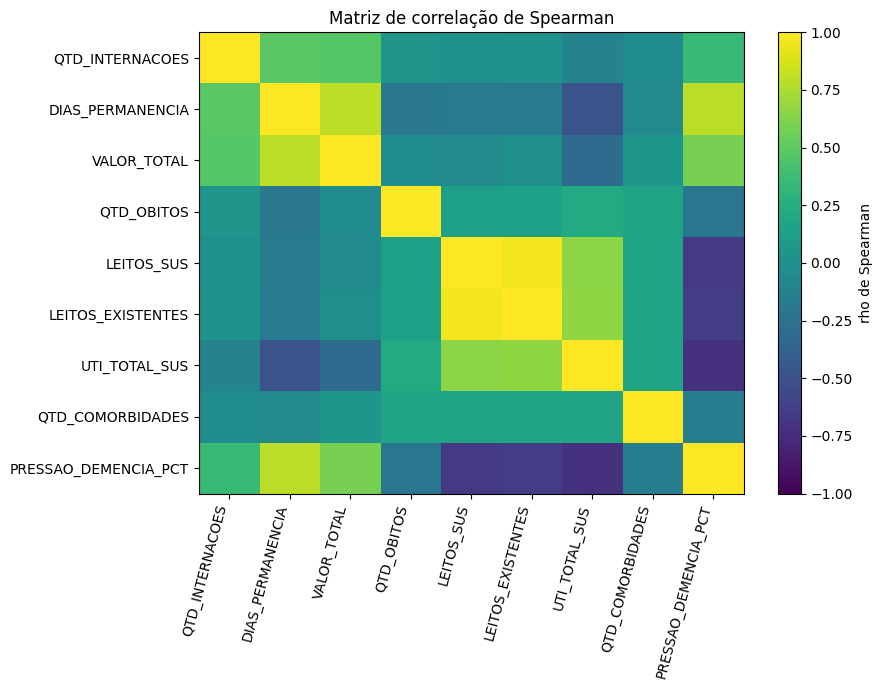

In [8]:
corr_vars=["QTD_INTERNACOES","DIAS_PERMANENCIA","VALOR_TOTAL","QTD_OBITOS","LEITOS_SUS","LEITOS_EXISTENTES","UTI_TOTAL_SUS","QTD_COMORBIDADES","PRESSAO_DEMENCIA_PCT"]
pearson=df[corr_vars].corr(method="pearson")
spearman=df[corr_vars].corr(method="spearman")

print("Correlação de Pearson")
display(pearson.round(3))
print("Correlação de Spearman")
display(spearman.round(3))

plt.figure(figsize=(9,7))
plt.imshow(spearman, aspect="auto", vmin=-1, vmax=1)
plt.colorbar(label="rho de Spearman")
plt.xticks(range(len(corr_vars)),corr_vars,rotation=75,ha="right")
plt.yticks(range(len(corr_vars)),corr_vars)
plt.title("Matriz de correlação de Spearman")
plt.tight_layout(); plt.show()

### Interpretação das correlações

A correlação muito alta entre `QTD_INTERNACOES`, `DIAS_PERMANENCIA` e `VALOR_TOTAL` em Pearson é parcialmente **mecânica**, porque as três medidas estão agregadas na mesma linha. Por isso, ela não deve ser interpretada como causalidade.

Para variáveis assimétricas e com outliers, a correlação de **Spearman** é mais informativa como análise complementar. A pressão proxy tende a aumentar com permanência e diminuir à medida que cresce a capacidade cadastrada, comportamento esperado pela própria fórmula do indicador. Portanto, essas correlações também não podem ser tratadas como descoberta causal independente.

## 9. Padrões clínicos, demográficos e temporais

In [9]:
# Distribuições ponderadas pela quantidade real de internações
def tabela_ponderada(campo):
    t=df.groupby(campo, dropna=False)["QTD_INTERNACOES"].sum().sort_values(ascending=False).to_frame("internacoes")
    t["pct"] = 100*t["internacoes"]/t["internacoes"].sum()
    return t

print("Faixa etária")
display(tabela_ponderada("FAIXA_ETARIA"))
print("Sexo")
display(tabela_ponderada("SEXO_DESC"))
print("Grupo CID principal")
display(tabela_ponderada("CID_GRUPO"))

faixa_cid=pd.pivot_table(df,index="FAIXA_ETARIA",columns="CID_GRUPO",values="QTD_INTERNACOES",aggfunc="sum",fill_value=0)
display(faixa_cid)

Faixa etária


,internacoes,pct
FAIXA_ETARIA,,
ATE_59,4016,57.486
70_79,1080,15.459
60_69,823,11.781
80_89,784,11.222
90_MAIS,283,4.051


Sexo


,internacoes,pct
SEXO_DESC,,
FEMININO,3544,50.730
MASCULINO,3442,49.270


Grupo CID principal


,internacoes,pct
CID_GRUPO,,
F02,3630,51.961
F03,1722,24.649
G30,1043,14.930
F00,355,5.082
F01,236,3.378


CID_GRUPO,F00,F01,F02,F03,G30
FAIXA_ETARIA,,,,,
60_69,94,85,162,357,125
70_79,74,56,97,573,280
80_89,64,44,43,208,425
90_MAIS,37,15,15,50,166
ATE_59,86,36,3313,534,47


### Ponto de atenção da AED

O recorte apresenta concentração elevada de internações classificadas como `ATE_59`, especialmente dentro do grupo **F02**. Esse padrão **não deve ser apagado como outlier**: ele deve ser auditado no dado-fonte e na regra de construção da faixa etária, porque pode refletir perfil específico de estabelecimentos, codificação clínica, longa permanência ou algum efeito do tratamento/agregação.

A AED transforma esse comportamento em uma pergunta de qualidade a ser validada antes de generalizar o modelo para o estado ou país.

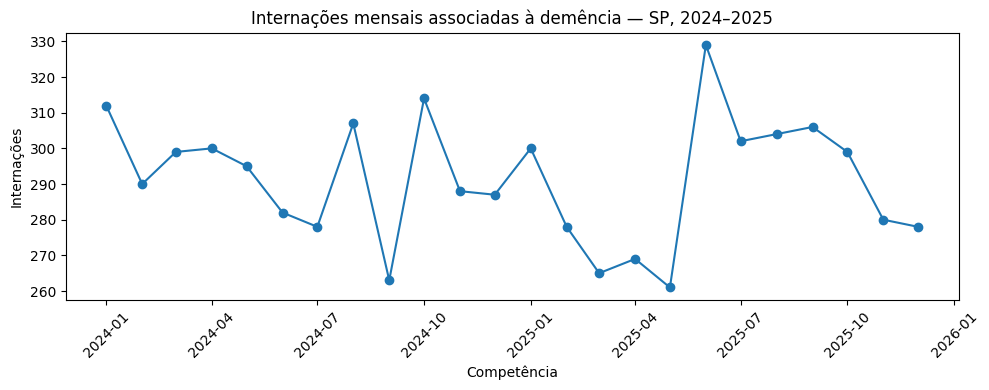

,DATA_COMPETENCIA,INTERNACOES,DIAS,VALOR,OBITOS
0,2024-01-01,312,7546,"524,504.630",11
1,2024-02-01,290,6846,"523,748.830",21
2,2024-03-01,299,7645,"543,886.080",16
3,2024-04-01,300,7286,"525,136.090",15
4,2024-05-01,295,7170,"503,991.000",24
5,2024-06-01,282,7103,"488,638.360",4
6,2024-07-01,278,7292,"516,646.240",13
7,2024-08-01,307,7273,"536,010.920",21
8,2024-09-01,263,5847,"408,798.410",14
9,2024-10-01,314,8065,"567,767.900",19


Média mensal: 291.1
Desvio-padrão mensal: 17.5
CV mensal: 6.0%


In [10]:
mensal=(df.groupby("DATA_COMPETENCIA",as_index=False)
        .agg(INTERNACOES=("QTD_INTERNACOES","sum"),DIAS=("DIAS_PERMANENCIA","sum"),VALOR=("VALOR_TOTAL","sum"),OBITOS=("QTD_OBITOS","sum")))

plt.figure(figsize=(10,4))
plt.plot(mensal["DATA_COMPETENCIA"],mensal["INTERNACOES"],marker="o")
plt.title("Internações mensais associadas à demência — SP, 2024–2025")
plt.xlabel("Competência"); plt.ylabel("Internações")
plt.xticks(rotation=45); plt.tight_layout(); plt.show()

display(mensal)
print(f"Média mensal: {mensal['INTERNACOES'].mean():.1f}")
print(f"Desvio-padrão mensal: {mensal['INTERNACOES'].std():.1f}")
print(f"CV mensal: {100*mensal['INTERNACOES'].std()/mensal['INTERNACOES'].mean():.1f}%")

## 10. Viabilidade preditiva — baseline temporal exploratório

O requisito principal desta entrega é AED, não a produção de um modelo final. Ainda assim, um baseline temporal ajuda a verificar se o dataset permite separar treino e teste sem vazamento.

Como existem apenas **24 competências (dois ciclos anuais)**, qualquer conclusão sazonal deve ser tratada como preliminar. O split abaixo respeita a ordem temporal.

,modelo,MAE,RMSE,R2
0,Naive lag-1,9.833,13.850,-0.474
1,Ridge temporal,43.532,45.435,-14.863


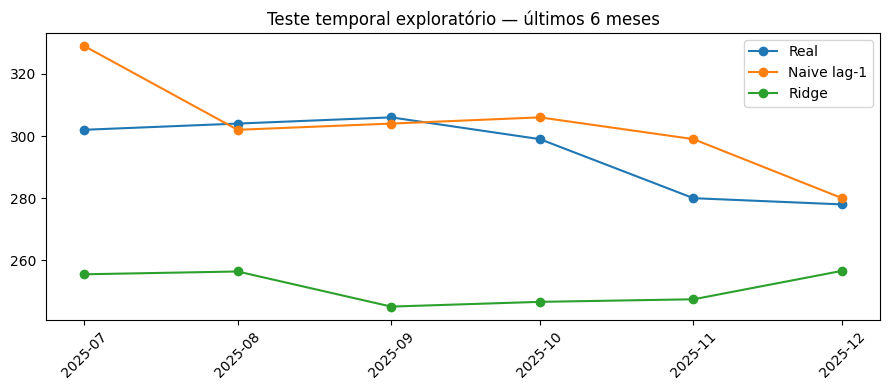

In [11]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

serie=mensal[["DATA_COMPETENCIA","INTERNACOES"]].copy().sort_values("DATA_COMPETENCIA")
serie["t"]=np.arange(len(serie))
serie["lag_1"]=serie["INTERNACOES"].shift(1)
serie["media_movel_3"]=serie["INTERNACOES"].shift(1).rolling(3).mean()  # somente passado
serie=serie.dropna().reset_index(drop=True)

# últimos 6 meses para teste
train=serie.iloc[:-6].copy(); test=serie.iloc[-6:].copy()
features=["t","lag_1","media_movel_3"]

model=Ridge(alpha=1.0)
model.fit(train[features],train["INTERNACOES"])
pred=model.predict(test[features])
naive=test["lag_1"].values

def metricas(y,p,nome):
    return {"modelo":nome,"MAE":mean_absolute_error(y,p),"RMSE":mean_squared_error(y,p)**0.5,"R2":r2_score(y,p)}

metricas_df=pd.DataFrame([metricas(test["INTERNACOES"],naive,"Naive lag-1"),metricas(test["INTERNACOES"],pred,"Ridge temporal")])
display(metricas_df.round(3))

plt.figure(figsize=(9,4))
plt.plot(test["DATA_COMPETENCIA"],test["INTERNACOES"],marker="o",label="Real")
plt.plot(test["DATA_COMPETENCIA"],naive,marker="o",label="Naive lag-1")
plt.plot(test["DATA_COMPETENCIA"],pred,marker="o",label="Ridge")
plt.title("Teste temporal exploratório — últimos 6 meses")
plt.legend(); plt.xticks(rotation=45); plt.tight_layout(); plt.show()

## 11. Conclusão da AED

A AED indica que o conjunto real da Sprint 3 é **viável para uma prova de conceito preditiva**, mas ainda exige cautela antes de sustentar decisões operacionais de alta consequência.

### Principais insights

1. **Integração consistente:** as 3.305 linhas analíticas representam 6.986 internações, distribuídas em 24 competências, 170 municípios e 281 estabelecimentos. A cobertura do merge com capacidade CNES é superior a 99%.
2. **Missings baixos e localizados:** a staging de internações não apresenta nulos; os missings relevantes surgem apenas na integração de capacidade para 11 linhas. A estratégia é não imputar leitos artificialmente.
3. **Distribuições não normais:** permanência, custo, leitos e pressão são assimétricos e rejeitam normalidade. Modelos e testes futuros devem respeitar essa estrutura, em vez de pressupor normalidade por conveniência.
4. **Outliers são informativos:** extremos em permanência, volume e custo podem representar longa permanência ou concentração institucional e devem ser auditados, não removidos automaticamente.
5. **Relações fortes precisam de interpretação:** algumas correlações decorrem do próprio processo de agregação e da fórmula da pressão; correlação não é evidência de causalidade.
6. **Padrão `ATE_59` + F02 merece auditoria:** a concentração observada é um insight de qualidade/negócio e deve ser validada antes da expansão nacional.
7. **Série temporal ainda curta:** 24 meses permitem baseline e validação temporal inicial, mas apenas dois ciclos anuais limitam inferência de sazonalidade e modelos mais complexos.
8. **Capacidade CNES é proxy:** leitos cadastrados não equivalem a leitos livres em tempo real. A `PRESSAO_DEMENCIA_PCT` mede pressão relativa associada à demência, não ocupação hospitalar total nem autorização de realocação.

### Implicação para a próxima etapa

O próximo passo recomendado é validar o ETL revisado com **demência em diagnóstico principal e secundário** sobre dados reais, recarregar o Oracle e repetir esta AED para medir quanto o filtro ampliado altera a demanda observada. Depois disso, a equipe pode comparar modelos temporais simples e regularizados com validação walk-forward, mantendo métricas como MAE, RMSE e WAPE.

> **Conclusão executiva:** os dados atuais suportam uma prova de conceito analítico-preditiva territorial, mas a equipe deve preservar a separação entre dado observado, proxy de capacidade, hipótese de subnotificação e previsão.

## 12. Checklist do enunciado

- [x] Dataset unificado com chaves explícitas.
- [x] Dicionário de dados completo.
- [x] Distribuições e assimetrias.
- [x] Média, mediana, desvio padrão e variabilidade.
- [x] Investigação de missings.
- [x] Estratégia de tratamento/imputação justificada.
- [x] Identificação de outliers por IQR e decisão justificada.
- [x] Relações entre variáveis com Pearson e Spearman.
- [x] Padrões clínicos, territoriais e temporais.
- [x] Conclusão da AED com implicações para modelagem.
- [x] Baseline temporal apenas como evidência adicional de viabilidade, sem apresentá-lo como modelo final.